# 06 · Autres modèles : lisse, hybride, CatBoost, réseau de neurones, mélanges

Un autre modèle que LightGBM peut-il faire mieux sur la prévision J+1, en particulier au froid ?

**Préalable :** le patch de production doit être appliqué (variables `dyn` et `nowcast` dans `conso.features`, moyenne de graines dans `conso.model`). La référence est le **modèle de production** : `FEATURE_COLUMNS` (55 variables), cible `conso − level7`, moyenne de plusieurs graines LightGBM. Tous les modèles reçoivent exactement les mêmes variables et la même cible : seule change la famille de modèle.

| Modèle | Idée | Ce qu'on en attend |
|---|---|---|
| `lgbm` | modèle de production, moyenne de graines | référence |
| `lgbm_1g` | même modèle, une seule graine | mesure l'apport de la moyenne de graines |
| `lisse` | un modèle linéaire régularisé par créneau de 30 min, avec splines sur la température | extrapole linéairement au-delà du froid déjà vu, biais fort, faible variance |
| `hybride` | `lisse` puis LightGBM sur le résidu | garde l'extrapolation du lisse et la souplesse des arbres |
| `catboost` | arbres symétriques, autre biais inductif | erreurs peu corrélées à celles de LightGBM |
| `mlp` | réseau de neurones avec embeddings (créneau, jour de semaine, mois) | prolonge la tendance (ReLU) et apporte de la diversité |
| `mel_*` | moyennes de modèles | réduction de variance par diversité |

## 0. Configuration

| Profil | Rolling origin | Arbres | Époques MLP | Usage |
|---|---|---|---|---|
| `smoke` | 1 / an dès 2022 | 30 | 4 | vérifier que tout s'exécute (résultats sans valeur) |
| `rapide` | 1 / an dès 2021 | 150 | 15 | premier coup d'œil |
| `standard` | 1 / an dès 2018 | 300 | 30 | profil de travail |
| `complet` | 1 / 6 mois dès 2018 | 600 | 40 | décision finale |

Le jeu 2025 et suivants n'est jamais utilisé pour choisir : il sert à la confirmation (section 10). Les résultats sont mis en cache dans `reports/model_experiments/cache/`.

In [1]:
import os, sys, time, json, hashlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import nnls
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import SplineTransformer

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 60
pd.options.display.width = 220
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
try:
    import conso
except ImportError:
    sys.path.insert(0, str(ROOT / "src"))
    import conso

from conso.config import GAP_DAYS, TZ, WCOLS
from conso.data import consolidated_end, load_dataset, load_national_forecast
from conso.features import FEATURE_COLUMNS, build_features, build_features_window
from conso.model import predict_level
from conso.timeutils import local_days, mask_between
from conso.weather import apply_hourly_bias, hourly_bias

try:
    from conso.model import fit_lgb_seeds
except ImportError as e:
    raise ImportError("Appliquer d'abord le patch de production (conso.model.fit_lgb_seeds).") from e
assert "y_last_rel" in FEATURE_COLUMNS, "Appliquer d'abord le patch de production (variables dyn et nowcast)."

try:
    from catboost import CatBoostRegressor
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
try:
    import torch
    from torch import nn
    torch.set_num_threads(os.cpu_count() or 1)
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False

RAW, PROC = ROOT / "data" / "raw", ROOT / "data" / "processed"
OUT = ROOT / "reports" / "model_experiments"
CACHE, FIGS = OUT / "cache", ROOT / "reports" / "figures"
for p in (CACHE, FIGS):
    p.mkdir(parents=True, exist_ok=True)


def ts(s):
    return pd.Timestamp(s, tz=TZ)


def save_fig(name):
    plt.savefig(FIGS / f"{name}.png", dpi=130, bbox_inches="tight")


PROFILE = os.environ.get("CONSO_NB_PROFILE", "standard")
PROFILES = {
    "smoke":    dict(eval_start="2022-01-01", retrain=12, rounds=30,  epochs_max=4,  seeds=2, n_boot=200,  confirm_retrain=12, confirm_rounds=40),
    "rapide":   dict(eval_start="2021-01-01", retrain=12, rounds=150, epochs_max=15, seeds=2, n_boot=500,  confirm_retrain=6,  confirm_rounds=300),
    "standard": dict(eval_start="2018-01-01", retrain=12, rounds=300, epochs_max=30, seeds=3, n_boot=2000, confirm_retrain=3,  confirm_rounds=1000),
    "complet":  dict(eval_start="2018-01-01", retrain=6,  rounds=600, epochs_max=40, seeds=3, n_boot=3000, confirm_retrain=1,  confirm_rounds=1000),
}
P = PROFILES[PROFILE]
ROUNDS, SEEDS = P["rounds"], P["seeds"]

TRAIN_START = ts("2013-01-01")
HOLDOUT_START = ts("2025-01-01")
EVAL_START = ts(P["eval_start"])
FC_EVAL_START = ts("2023-01-01")
BIAS_MONTHS = 24
EVAL_EXCLUDE = [(ts("2020-03-01"), ts("2021-07-01"))]
FORCE_REFRESH = False
print(f"Profil : {PROFILE} | {P} | catboost : {HAS_CATBOOST} | torch : {HAS_TORCH}")

Profil : standard | {'eval_start': '2018-01-01', 'retrain': 12, 'rounds': 300, 'epochs_max': 30, 'seeds': 3, 'n_boot': 2000, 'confirm_retrain': 3, 'confirm_rounds': 1000} | catboost : True | torch : True


## 1. Données et variables

Les variables sont celles de la production, calculées par `conso.features` : en mode oracle sur tout l'historique, en mode prévu mois par mois avec `build_features_window` (météo prévue débiaisée par heure, biais réestimé chaque mois sur les 24 mois précédents), comme dans `conso.backtest`.

In [2]:
df = load_dataset(PROC / "dataset_30min.parquet")
y = df["conso"]
wt_obs = df[WCOLS]
TEST_END = consolidated_end(df).tz_convert(TZ)
HAS_FC = (RAW / "meteo_forecast_openmeteo.parquet").exists()
WT_FC = load_national_forecast(RAW / "meteo_forecast_openmeteo.parquet", df.index) if HAS_FC else None
MODES = ["oracle", "fc_debiased"] if HAS_FC else ["oracle"]

FEATS = list(FEATURE_COLUMNS)
X_OBS = build_features(df, wt_obs)
CHK = round(float(np.nansum(X_OBS[FEATS].iloc[::997].to_numpy(dtype=float))), 3)
_FC = {}


def fc_month(ms):
    if ms not in _FC:
        me = ms + pd.DateOffset(months=1)
        fin = ms - pd.Timedelta(days=GAP_DAYS)
        biais = hourly_bias(WT_FC, wt_obs, fin - pd.DateOffset(months=BIAS_MONTHS), fin)
        _FC[ms] = build_features_window(df, apply_hourly_bias(WT_FC, biais), ms, me)
    return _FC[ms]


print(f"{len(df):,} lignes, {len(FEATS)} variables, consolidé jusqu'au {TEST_END}, modes : {MODES}")

240,458 lignes, 55 variables, consolidé jusqu'au 2026-07-01 00:00:00+02:00, modes : ['oracle', 'fc_debiased']


## 2. Les modèles

Tous exposent `fit(X, y, mask, ref_end)` et `predict(X_variables)`, et prédisent l'écart au niveau récent `level7` (comme la production).

- **`Lisse`** : pour chaque créneau de 30 min, une régression Ridge sur des splines de la température (`temp_nat`, `te`, `te_lent`, extrapolation linéaire aux bords), le jour de la semaine, deux harmoniques annuelles et les autres variables en linéaire. La pénalisation est choisie par validation croisée interne.
- **`Hybride`** : `Lisse`, puis LightGBM entraîné sur son résidu.
- **`Cat`** : CatBoost, arbres symétriques de profondeur 8.
- **`MLP`** : trois couches cachées, embeddings du créneau, du jour de semaine et du mois, indicateurs de valeurs manquantes, perte de Huber, OneCycle, moyenne de plusieurs graines.

In [3]:
class LGBM:
    def __init__(self, seeds=1, rounds=None, params=None, seed0=0):
        self.seeds, self.rounds, self.params, self.seed0 = seeds, rounds or ROUNDS, params or {}, seed0

    def fit(self, X, y, mask, ref_end):
        self.m = fit_lgb_seeds(X, y, mask, self.rounds, {**self.params, "seed": self.seed0}, None, ref_end, FEATS, n_seeds=self.seeds)
        return self

    def predict(self, Xf):
        return self.m.predict(Xf)


SPLINES = ["temp_nat", "te", "te_lent"]
LINEAIRES = [c for c in FEATS if c not in SPLINES + ["heure", "jour_semaine", "mois", "jour_annee"]]


class Lisse:
    def __init__(self, alphas=(1.0, 10.0, 100.0, 1000.0), n_knots=7):
        self.alphas, self.n_knots = alphas, n_knots

    def _design(self, Xf):
        lin = Xf[LINEAIRES].to_numpy(dtype=float)
        lin = np.where(np.isnan(lin), self.med_lin, lin)
        spl = [self.spl[c].transform(Xf[[c]].fillna(self.med_spl[c]).to_numpy()) for c in SPLINES]
        dow = np.eye(7)[Xf["jour_semaine"].to_numpy(dtype=int)]
        ang = 2 * np.pi * Xf["jour_annee"].to_numpy(dtype=float) / 365.25
        saison = np.column_stack([np.sin(ang), np.cos(ang), np.sin(2 * ang), np.cos(2 * ang)])
        return np.hstack([*spl, lin, dow, saison])

    def fit(self, X, y, mask, ref_end):
        tgt = y - X["level7"]
        tr = mask & tgt.notna().to_numpy()
        Xf = X.loc[tr, FEATS]
        self.med_lin = np.nan_to_num(np.nanmedian(Xf[LINEAIRES].to_numpy(dtype=float), axis=0), nan=0.0)
        self.med_spl = {c: float(np.nanmedian(Xf[c])) for c in SPLINES}
        self.spl = {c: SplineTransformer(n_knots=self.n_knots, degree=3, knots="quantile", extrapolation="linear").fit(Xf[[c]].fillna(self.med_spl[c]).to_numpy()) for c in SPLINES}
        Z = self._design(Xf)
        self.mu, self.sd = Z.mean(axis=0), Z.std(axis=0)
        self.sd[self.sd == 0] = 1.0
        Z = (Z - self.mu) / self.sd
        slot = np.rint(Xf["heure"].to_numpy(dtype=float) * 2).astype(int)
        t = tgt[tr].to_numpy(dtype=float)
        self.models = {s: RidgeCV(alphas=self.alphas).fit(Z[slot == s], t[slot == s]) for s in np.unique(slot)}
        return self

    def predict(self, Xf):
        Z = (self._design(Xf) - self.mu) / self.sd
        slot = np.rint(Xf["heure"].to_numpy(dtype=float) * 2).astype(int)
        out = np.full(len(Xf), np.nan)
        for s, m in self.models.items():
            k = slot == s
            if k.any():
                out[k] = m.predict(Z[k])
        return out


class Hybride:
    def __init__(self, seeds=1, rounds=None, seed0=0):
        self.seeds, self.rounds, self.seed0 = seeds, rounds or ROUNDS, seed0

    def fit(self, X, y, mask, ref_end):
        self.lisse = Lisse().fit(X, y, mask, ref_end)
        base = pd.Series(self.lisse.predict(X[FEATS]), index=X.index)
        self.gb = fit_lgb_seeds(X, y - base, mask & base.notna().to_numpy(), self.rounds, {"seed": self.seed0}, None, ref_end, FEATS, n_seeds=self.seeds)
        return self

    def predict(self, Xf):
        return self.lisse.predict(Xf) + self.gb.predict(Xf)


class Cat:
    def __init__(self, seeds=1, iters=None, depth=8):
        self.seeds, self.iters, self.depth = seeds, iters or ROUNDS, depth

    def fit(self, X, y, mask, ref_end):
        tgt = y - X["level7"]
        tr = mask & tgt.notna().to_numpy()
        self.ms = [CatBoostRegressor(iterations=self.iters, depth=self.depth, learning_rate=0.1, eval_metric="MAE", random_seed=s,
                                     verbose=0, thread_count=-1, allow_writing_files=False).fit(X.loc[tr, FEATS], tgt[tr]) for s in range(self.seeds)]
        return self

    def predict(self, Xf):
        return np.mean([m.predict(Xf) for m in self.ms], axis=0)


CATEGORIELLES = ["heure", "jour_semaine", "mois"]
NUM_COLS = [c for c in FEATS if c not in CATEGORIELLES]

if HAS_TORCH:
    class _Net(nn.Module):
        def __init__(self, n_in, hidden, drop):
            super().__init__()
            self.e_slot, self.e_dow, self.e_mois = nn.Embedding(48, 8), nn.Embedding(7, 3), nn.Embedding(12, 3)
            self.mlp = nn.Sequential(
                nn.Linear(n_in + 14, hidden), nn.SiLU(), nn.Dropout(drop),
                nn.Linear(hidden, hidden), nn.SiLU(), nn.Dropout(drop),
                nn.Linear(hidden, hidden // 2), nn.SiLU(), nn.Linear(hidden // 2, 1))

        def forward(self, x, c):
            return self.mlp(torch.cat([x, self.e_slot(c[:, 0]), self.e_dow(c[:, 1]), self.e_mois(c[:, 2])], dim=1)).squeeze(1)


class MLP:
    def __init__(self, seeds=1, epochs=20, hidden=256, drop=0.1, lr=2e-3, wd=1e-4, bs=1024):
        self.seeds, self.epochs, self.hidden, self.drop, self.lr, self.wd, self.bs = seeds, epochs, hidden, drop, lr, wd, bs

    def _prep(self, Xf, fit=False):
        num = Xf[NUM_COLS].to_numpy(dtype=float)
        miss = np.isnan(num)
        if fit:
            self.med = np.nan_to_num(np.nanmedian(num, axis=0), nan=0.0)
            self.miss_idx = np.where(miss.any(axis=0))[0]
        num = np.where(miss, self.med, num)
        if fit:
            self.mu, self.sd = num.mean(axis=0), num.std(axis=0)
            self.sd[self.sd == 0] = 1.0
        z = np.hstack([(num - self.mu) / self.sd, miss[:, self.miss_idx]]).astype(np.float32)
        cat = np.column_stack([np.rint(Xf["heure"].to_numpy(dtype=float) * 2), Xf["jour_semaine"].to_numpy(dtype=float), Xf["mois"].to_numpy(dtype=float) - 1])
        cat = np.minimum(np.clip(np.nan_to_num(cat), 0, None), [47, 6, 11]).astype(np.int64)
        return torch.from_numpy(z), torch.from_numpy(cat)

    def fit(self, X, y, mask, ref_end, val_mask=None):
        tgt = (y - X["level7"]).to_numpy(dtype=float)
        tr = mask & ~np.isnan(tgt)
        z, c = self._prep(X.loc[tr, FEATS], fit=True)
        self.ts = float(np.std(tgt[tr]))
        t = torch.from_numpy((tgt[tr] / self.ts).astype(np.float32))
        if val_mask is not None:
            vm = val_mask & ~np.isnan(tgt)
            zv, cv = self._prep(X.loc[vm, FEATS])
            tv = tgt[vm]
        self.nets, self.curve = [], []
        n = len(t)
        steps = int(np.ceil(n / self.bs))
        for s in range(self.seeds):
            torch.manual_seed(s)
            net = _Net(z.shape[1], self.hidden, self.drop)
            opt = torch.optim.AdamW(net.parameters(), lr=self.lr, weight_decay=self.wd)
            sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=self.lr, total_steps=self.epochs * steps)
            loss_fn = nn.SmoothL1Loss(beta=0.3)
            for ep in range(self.epochs):
                net.train()
                perm = torch.randperm(n)
                for i in range(0, n, self.bs):
                    idx = perm[i:i + self.bs]
                    opt.zero_grad()
                    loss_fn(net(z[idx], c[idx]), t[idx]).backward()
                    opt.step()
                    sched.step()
                if val_mask is not None and s == 0:
                    net.eval()
                    with torch.no_grad():
                        self.curve.append(float(np.mean(np.abs(net(zv, cv).numpy() * self.ts - tv))))
            self.nets.append(net.eval())
        return self

    def predict(self, Xf):
        z, c = self._prep(Xf)
        with torch.no_grad():
            return np.mean([np.concatenate([n(z[i:i + 50000], c[i:i + 50000]).numpy() for i in range(0, len(z), 50000)]) for n in self.nets], axis=0) * self.ts


def make_model(spec):
    k = spec["kind"]
    if k == "lgbm":
        return LGBM(spec["seeds"], spec.get("rounds"), seed0=spec.get("seed0", 0))
    if k == "lisse":
        return Lisse()
    if k == "hybride":
        return Hybride(spec["seeds"], spec.get("rounds"))
    if k == "catboost":
        return Cat(spec["seeds"], spec.get("iters"))
    if k == "mlp":
        return MLP(spec["seeds"], spec["epochs"])
    raise ValueError(k)

## 3. Moteur d'expériences et outils de mesure

Même protocole que le notebook 05 : rolling origin, entraînement sur la météo **observée**, prévision en mode **oracle** (météo observée) et en mode **prévu débiaisé** (2023 et suivants). Le gain est `(MAE_réf − MAE_variante) / MAE_réf`, son IC vient d'un bootstrap par blocs de 7 jours sur les erreurs journalières appariées, et le verdict tient compte de la multiplicité et du bruit de graine :

✅ gain robuste (borne basse de l'IC corrigé de Bonferroni > 0 et gain > 2 × bruit) · 🟡 probable (IC à 95 % > 0) · ⚪ non concluant · ❌ dégradation.

Périmètres : `global`, `froid` (température moyenne journalière ≤ 3 °C), `grand_froid` (≤ 0 °C).

In [4]:
PRED, FIT_SEC, NOISE = {}, {}, {}
EXCL = np.zeros(len(df), dtype=bool)
for a, b in EVAL_EXCLUDE:
    EXCL |= mask_between(df.index, a, b)
EXCL_S = pd.Series(EXCL, index=df.index)
LOCAL_DAY = pd.Series(local_days(df.index), index=df.index)
T_DAY_OBS = df["temp_nat"].groupby(LOCAL_DAY.to_numpy()).mean()
SCOPE_MASK = {"global": pd.Series(True, index=T_DAY_OBS.index), "froid": T_DAY_OBS <= 3.0, "grand_froid": T_DAY_OBS <= 0.0}
if "prevision_j1" in df.columns:
    PRED["rte_j1"] = pd.DataFrame({m: df["prevision_j1"] for m in MODES})


def run_model(name, spec, *, start=None, end=None, retrain=None, modes=None, exclude_train=None, force=False):
    start, end = start or EVAL_START, end or HOLDOUT_START
    retrain, modes = retrain or P["retrain"], list(modes or MODES)
    excl = None if exclude_train is None else hashlib.md5(np.packbits(exclude_train).tobytes()).hexdigest()
    key = json.dumps(dict(spec=spec, a=str(start), b=str(end), rt=retrain, modes=modes, chk=CHK, v=conso.__version__, excl=excl), sort_keys=True, default=str)
    path = CACHE / f"{name}_{hashlib.md5(key.encode()).hexdigest()[:10]}.parquet"
    side = path.with_suffix(".json")
    if path.exists() and not force and not FORCE_REFRESH:
        PRED[name] = pd.read_parquet(path)
        FIT_SEC[name] = json.loads(side.read_text())["sec_par_entrainement"] if side.exists() else np.nan
        print(f"  {name:26s} cache")
        return
    months = list(pd.date_range(start, end - pd.Timedelta("1min"), freq="MS"))
    parts, n_fit, t_fit = [], 0, 0.0
    for k in range(0, len(months), retrain):
        blk = months[k:k + retrain]
        train_end = blk[0] - pd.Timedelta(days=GAP_DAYS)
        tm = mask_between(X_OBS.index, TRAIN_START, train_end)
        if exclude_train is not None:
            tm = tm & ~exclude_train
        t0 = time.time()
        model = make_model(spec).fit(X_OBS, y, tm, train_end)
        t_fit += time.time() - t0
        n_fit += 1
        for ms in blk:
            me = ms + pd.DateOffset(months=1)
            out = {"oracle": predict_level(model, X_OBS.loc[mask_between(X_OBS.index, ms, me)], FEATS)}
            if "fc_debiased" in modes and ms >= FC_EVAL_START:
                out["fc_debiased"] = predict_level(model, fc_month(ms), FEATS)
            parts.append(pd.DataFrame(out))
    PRED[name] = pd.concat(parts)
    PRED[name].to_parquet(path)
    FIT_SEC[name] = t_fit / n_fit
    side.write_text(json.dumps({"sec_par_entrainement": FIT_SEC[name], "n": n_fit}))
    print(f"  {name:26s} {n_fit:3d} entraînements, {t_fit:6.0f} s ({FIT_SEC[name]:.1f} s par entraînement)")


def eval_frame(names, mode, start=None, end=None):
    start, end = start or EVAL_START, end or HOLDOUT_START
    if mode == "fc_debiased":
        start = max(start, FC_EVAL_START)
    fr = pd.DataFrame({n: PRED[n][mode] for n in names})
    fr["y"] = y
    fr = fr.loc[(fr.index >= start) & (fr.index < end)]
    return fr.loc[~EXCL_S.reindex(fr.index).to_numpy()].dropna()


def metrics_table(names, mode, start=None, end=None):
    fr = eval_frame(names, mode, start, end)
    d = LOCAL_DAY.reindex(fr.index).to_numpy()
    ymax, rows = fr["y"].groupby(d).max(), {}
    for n in names:
        e = fr[n] - fr["y"]
        rows[n] = {"MAE": e.abs().mean(), "RMSE": np.sqrt((e ** 2).mean()), "biais": e.mean(), "MAPE %": (e.abs() / fr["y"]).mean() * 100,
                   "err_pointe": (fr[n].groupby(d).max() - ymax).abs().mean(), "n": len(e)}
    return pd.DataFrame(rows).T


def boot_gain(a, b, n_boot, block=7, seed=0, alpha_adj=0.05):
    a, b = np.asarray(a, float), np.asarray(b, float)
    n = len(a)
    g0 = (a.mean() - b.mean()) / a.mean() * 100
    if n < 8:
        return dict(gain=g0, lo=np.nan, hi=np.nan, lo_b=np.nan)
    rng = np.random.default_rng(seed)
    blk = min(block, n)
    starts = rng.integers(0, n, size=(n_boot, int(np.ceil(n / blk))))
    idx = ((starts[:, :, None] + np.arange(blk)) % n).reshape(n_boot, -1)[:, :n]
    ma, mb = a[idx].mean(axis=1), b[idx].mean(axis=1)
    g = (ma - mb) / ma * 100
    return dict(gain=g0, lo=np.quantile(g, 0.025), hi=np.quantile(g, 0.975), lo_b=np.quantile(g, alpha_adj / 2))


def verdict(g, lo, hi, lo_b, noise):
    if np.isnan(lo):
        return "n/a"
    if lo_b > 0 and g > 2 * noise:
        return "✅"
    if lo > 0:
        return "🟡"
    if hi < 0:
        return "❌"
    return "⚪"


def compare(names, ref="lgbm", mode="oracle", scopes=("global", "froid", "grand_froid"), start=None, end=None, K=None):
    fr = eval_frame([ref, *names], mode, start, end)
    E = fr[[ref, *names]].sub(fr["y"], axis=0).abs()
    daily = E.groupby(LOCAL_DAY.reindex(E.index).to_numpy()).mean()
    alpha_adj = 0.05 / max(K or len(names), 1)
    rows = []
    for n in names:
        row = {"variante": n, "MAE": E[n].mean(), "MAE_réf": E[ref].mean()}
        for sc in scopes:
            dm = daily.loc[SCOPE_MASK[sc].reindex(daily.index).fillna(False).to_numpy(dtype=bool)]
            r = boot_gain(dm[ref], dm[n], P["n_boot"], alpha_adj=alpha_adj)
            row.update({f"gain_{sc}": r["gain"], f"lo_{sc}": r["lo"], f"hi_{sc}": r["hi"], f"n_{sc}": len(dm),
                        f"verdict_{sc}": verdict(r["gain"], r["lo"], r["hi"], r["lo_b"], NOISE.get((mode, sc), 0.0))})
        rows.append(row)
    return pd.DataFrame(rows).set_index("variante")


def pretty(tab, scopes=("global", "froid", "grand_froid")):
    out = pd.DataFrame(index=tab.index)
    out["MAE"] = tab["MAE"].round(0)
    for sc in scopes:
        n = int(tab[f"n_{sc}"].iloc[0]) if len(tab) else 0
        out[f"{sc} ({n} j)"] = [f"{g:+.2f} % [{lo:+.2f} ; {hi:+.2f}] {v}" for g, lo, hi, v in
                                zip(tab[f"gain_{sc}"], tab[f"lo_{sc}"], tab[f"hi_{sc}"], tab[f"verdict_{sc}"])]
    return out


def slice_gain(name, ref, mode, by, start=None, end=None):
    fr = eval_frame([ref, name], mode, start, end)
    E = fr[[ref, name]].sub(fr["y"], axis=0).abs()
    loc = fr.index.tz_convert(TZ)
    if by == "année":
        key = pd.Index(loc.year)
    elif by == "saison":
        key = pd.Index(np.where(loc.month.isin([11, 12, 1, 2, 3]), "hiver", np.where(loc.month.isin([6, 7, 8, 9]), "été", "mi-saison")))
    else:
        key = pd.Index(pd.cut(df.loc[fr.index, "temp_nat"].to_numpy(), [-np.inf, 0, 5, 10, 15, 20, 25, np.inf], labels=["<0", "0-5", "5-10", "10-15", "15-20", "20-25", ">25"]))
    g = E.groupby(key, observed=True).mean()
    return (g[ref] - g[name]) / g[ref] * 100


def add_blend(name, parts, weights=None):
    w = np.full(len(parts), 1 / len(parts)) if weights is None else np.asarray(weights, dtype=float)
    modes = [m for m in MODES if all(m in PRED[p].columns for p in parts)]
    PRED[name] = pd.DataFrame({m: sum(wi * PRED[p][m] for wi, p in zip(w, parts)) for m in modes})

## 4. Référence, bruit de graine et réglage du réseau

`lgbm` est le modèle de production. `lgbm_s1` est le même modèle avec d'autres graines : l'écart entre les deux est le **bruit** que produit le hasard seul, et sert de seuil aux verdicts.

Le nombre d'époques du réseau est choisi **avant** la période de sélection : on l'entraîne sur les années précédentes et on mesure l'erreur sur les 12 mois qui précèdent `EVAL_START`.

Référence et bruit de graine
  lgbm                         7 entraînements,    566 s (80.9 s par entraînement)
  lgbm_s1                      7 entraînements,    491 s (70.1 s par entraînement)
  lgbm_1g                      7 entraînements,    124 s (17.7 s par entraînement)

Bruit de graine de la moyenne de graines (points de % de MAE) :


bruit %
oracle      global         0.193
            froid          0.661
            grand_froid    2.582
fc_debiased global         0.502
            froid          0.098
            grand_froid    3.049


Réseau : 30 époques en 206 s, meilleure époque de validation : 23


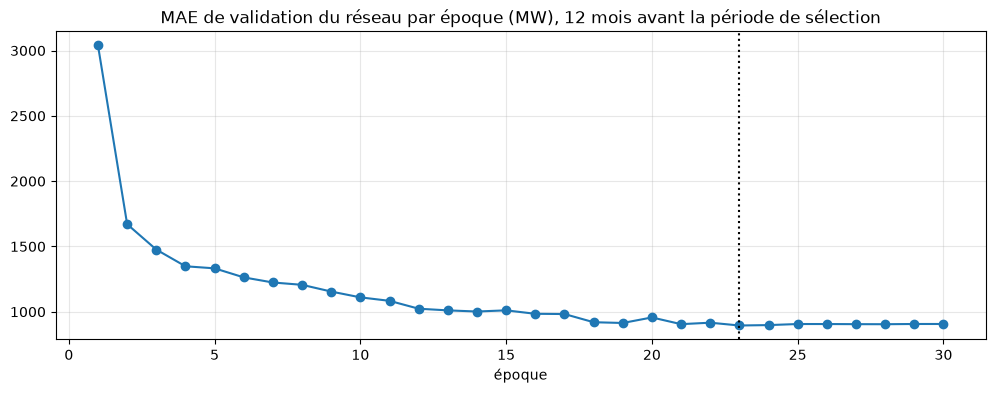

In [5]:
print("Référence et bruit de graine")
run_model("lgbm", dict(kind="lgbm", seeds=SEEDS, rounds=ROUNDS))
run_model("lgbm_s1", dict(kind="lgbm", seeds=SEEDS, rounds=ROUNDS, seed0=100))
run_model("lgbm_1g", dict(kind="lgbm", seeds=1, rounds=ROUNDS))
for mode in MODES:
    for sc in SCOPE_MASK:
        NOISE[(mode, sc)] = float(compare(["lgbm_s1"], mode=mode, scopes=(sc,))[f"gain_{sc}"].abs().iloc[0])
print("\nBruit de graine de la moyenne de graines (points de % de MAE) :")
display(pd.DataFrame(NOISE, index=["bruit %"]).T.round(3))

EPOCHS = None
if HAS_TORCH:
    fin_cal = EVAL_START - pd.Timedelta(days=GAP_DAYS)
    debut_val = fin_cal - pd.DateOffset(months=12)
    entrainement = mask_between(X_OBS.index, TRAIN_START, debut_val - pd.Timedelta(days=GAP_DAYS))
    validation = mask_between(X_OBS.index, debut_val, fin_cal)
    t0 = time.time()
    cal = MLP(seeds=1, epochs=P["epochs_max"]).fit(X_OBS, y, entrainement, None, val_mask=validation)
    EPOCHS = int(np.argmin(cal.curve)) + 1
    print(f"\nRéseau : {P['epochs_max']} époques en {time.time() - t0:.0f} s, meilleure époque de validation : {EPOCHS}")
    plt.plot(range(1, len(cal.curve) + 1), cal.curve, marker="o")
    plt.axvline(EPOCHS, color="k", ls=":")
    plt.title("MAE de validation du réseau par époque (MW), 12 mois avant la période de sélection")
    plt.xlabel("époque")
    save_fig("06_courbe_mlp")
    plt.show()

## 5. Criblage des modèles

Chaque modèle est comparé au modèle de production `lgbm`, dans les deux modes. Tous les modèles à graines utilisent le même nombre de graines que la référence.

In [6]:
SPECS = {
    "lisse": dict(kind="lisse"),
    "hybride": dict(kind="hybride", seeds=SEEDS, rounds=ROUNDS),
}
if HAS_CATBOOST:
    SPECS["catboost"] = dict(kind="catboost", seeds=SEEDS, iters=ROUNDS)
if HAS_TORCH:
    SPECS["mlp"] = dict(kind="mlp", seeds=SEEDS, epochs=EPOCHS)
print("Modèles alternatifs")
for name, spec in SPECS.items():
    run_model(name, spec)

names = ["lgbm_1g", *SPECS]
SCREEN = {}
for mode in MODES:
    SCREEN[mode] = compare(names, mode=mode)
    print(f"\n=== Mode {mode}, gain par rapport à lgbm (production) ===")
    display(pretty(SCREEN[mode]))
print("\n✅ robuste · 🟡 probable · ⚪ non concluant · ❌ dégradation")

Modèles alternatifs
  lisse                        7 entraînements,     22 s (3.1 s par entraînement)
  hybride                      7 entraînements,    556 s (79.4 s par entraînement)
  catboost                     7 entraînements,    638 s (91.2 s par entraînement)
  mlp                          7 entraînements,   6226 s (889.5 s par entraînement)

=== Mode oracle, gain par rapport à lgbm (production) ===


,MAE,global (2070 j),froid (103 j),grand_froid (12 j)
variante,,,,
lgbm_1g,888.0,-5.05 % [-5.86 ; -4.26] ❌,-2.00 % [-5.30 ; +0.97] ⚪,-4.31 % [-7.84 ; -1.54] ❌
lisse,880.0,-4.12 % [-9.72 ; +1.10] ⚪,+24.75 % [+10.77 ; +39.56] ✅,+40.80 % [-3.54 ; +65.25] ⚪
hybride,753.0,+10.95 % [+7.09 ; +14.47] ✅,+28.66 % [+18.03 ; +40.27] ✅,+47.36 % [+11.42 ; +66.43] ✅
catboost,847.0,-0.26 % [-1.90 ; +1.34] ⚪,+4.53 % [-0.71 ; +9.47] ⚪,+0.60 % [-13.02 ; +10.90] ⚪
mlp,719.0,+14.98 % [+12.12 ; +17.70] ✅,+21.81 % [+8.99 ; +34.96] ✅,+43.60 % [+20.48 ; +57.71] ✅



=== Mode fc_debiased, gain par rapport à lgbm (production) ===


,MAE,global (731 j),froid (35 j),grand_froid (4 j)
variante,,,,
lgbm_1g,884.0,-4.83 % [-6.38 ; -3.43] ❌,-2.66 % [-5.67 ; -0.02] ❌,-0.11 % [+nan ; +nan] n/a
lisse,908.0,-7.67 % [-17.03 ; +0.81] ⚪,+37.61 % [+16.39 ; +56.41] ✅,+58.24 % [+nan ; +nan] n/a
hybride,819.0,+2.91 % [-3.44 ; +9.17] ⚪,+32.86 % [+14.60 ; +50.05] ✅,+58.97 % [+nan ; +nan] n/a
catboost,847.0,-0.53 % [-2.56 ; +1.53] ⚪,+3.29 % [-3.92 ; +9.57] ⚪,+8.95 % [+nan ; +nan] n/a
mlp,764.0,+9.42 % [+4.16 ; +14.70] ✅,+28.09 % [+7.20 ; +47.11] ✅,+49.32 % [+nan ; +nan] n/a



✅ robuste · 🟡 probable · ⚪ non concluant · ❌ dégradation


## 6. Mélanges

La moyenne de modèles aux erreurs peu corrélées réduit la variance. On teste des **moyennes simples** (sans rien apprendre) et une moyenne à **poids appris** par moindres carrés positifs sur la période de sélection en mode oracle. Ces poids étant appris sur les mêmes données que l'évaluation, ce dernier mélange est optimiste ici : seule la confirmation sur 2025 et suivants compte pour lui.

In [7]:
BASES = [m for m in ("hybride", "catboost", "mlp", "lisse") if m in PRED]
BLENDS = {f"mel_lgbm_{m}": ["lgbm", m] for m in BASES}
if len(BASES) >= 2:
    BLENDS["mel_tous"] = ["lgbm", *BASES]
for name, parts in BLENDS.items():
    add_blend(name, parts)

W_NNLS = None
if len(BASES) >= 1:
    comp = ["lgbm", *BASES]
    fr = eval_frame(comp, "oracle")
    niveau = X_OBS["level7"].reindex(fr.index).to_numpy()
    w, _ = nnls(fr[comp].sub(niveau, axis=0).to_numpy(dtype=float), (fr["y"].to_numpy() - niveau))
    W_NNLS = pd.Series(w / w.sum(), index=comp)
    add_blend("mel_nnls", comp, W_NNLS.to_numpy())
    print("Poids appris (mel_nnls) :", W_NNLS.round(3).to_dict())

names_b = [*BLENDS, *(["mel_nnls"] if W_NNLS is not None else [])]
SCREEN_B = {}
for mode in MODES:
    SCREEN_B[mode] = compare(names_b, mode=mode)
    print(f"\n=== Mode {mode}, mélanges : gain par rapport à lgbm ===")
    display(pretty(SCREEN_B[mode]))

Poids appris (mel_nnls) : {'lgbm': 0.086, 'hybride': 0.392, 'catboost': 0.02, 'mlp': 0.502, 'lisse': 0.0}

=== Mode oracle, mélanges : gain par rapport à lgbm ===


,MAE,global (2070 j),froid (103 j),grand_froid (12 j)
variante,,,,
mel_lgbm_hybride,725.0,+14.19 % [+12.34 ; +15.86] ✅,+20.72 % [+15.29 ; +26.15] ✅,+32.06 % [+18.43 ; +42.43] ✅
mel_lgbm_catboost,815.0,+3.59 % [+2.73 ; +4.39] ✅,+4.77 % [+1.76 ; +7.70] ✅,+1.62 % [-4.71 ; +6.73] ⚪
mel_lgbm_mlp,715.0,+15.42 % [+14.07 ; +16.79] ✅,+18.51 % [+12.33 ; +24.97] ✅,+27.19 % [+15.43 ; +34.42] ✅
mel_lgbm_lisse,774.0,+8.42 % [+5.78 ; +10.84] ✅,+20.05 % [+12.78 ; +27.35] ✅,+32.25 % [+13.02 ; +45.95] ✅
mel_tous,704.0,+16.69 % [+14.41 ; +18.82] ✅,+24.91 % [+18.06 ; +32.09] ✅,+37.05 % [+18.61 ; +47.71] ✅
mel_nnls,676.0,+19.99 % [+17.29 ; +22.46] ✅,+29.00 % [+19.11 ; +39.81] ✅,+49.19 % [+25.54 ; +62.19] ✅



=== Mode fc_debiased, mélanges : gain par rapport à lgbm ===


,MAE,global (731 j),froid (35 j),grand_froid (4 j)
variante,,,,
mel_lgbm_hybride,765.0,+9.27 % [+6.28 ; +12.06] ✅,+19.18 % [+10.33 ; +27.17] ✅,+30.06 % [+nan ; +nan] n/a
mel_lgbm_catboost,817.0,+3.14 % [+2.07 ; +4.29] ✅,+2.83 % [-0.91 ; +6.26] ⚪,+5.02 % [+nan ; +nan] n/a
mel_lgbm_mlp,748.0,+11.32 % [+8.93 ; +13.81] ✅,+17.76 % [+7.62 ; +26.72] ✅,+25.79 % [+nan ; +nan] n/a
mel_lgbm_lisse,794.0,+5.79 % [+1.55 ; +9.50] ✅,+23.07 % [+12.71 ; +32.67] ✅,+31.75 % [+nan ; +nan] n/a
mel_tous,744.0,+11.79 % [+8.29 ; +15.21] ✅,+25.30 % [+13.91 ; +35.35] ✅,+36.74 % [+nan ; +nan] n/a
mel_nnls,735.0,+12.84 % [+8.36 ; +17.36] ✅,+30.32 % [+13.44 ; +46.01] ✅,+49.00 % [+nan ; +nan] n/a


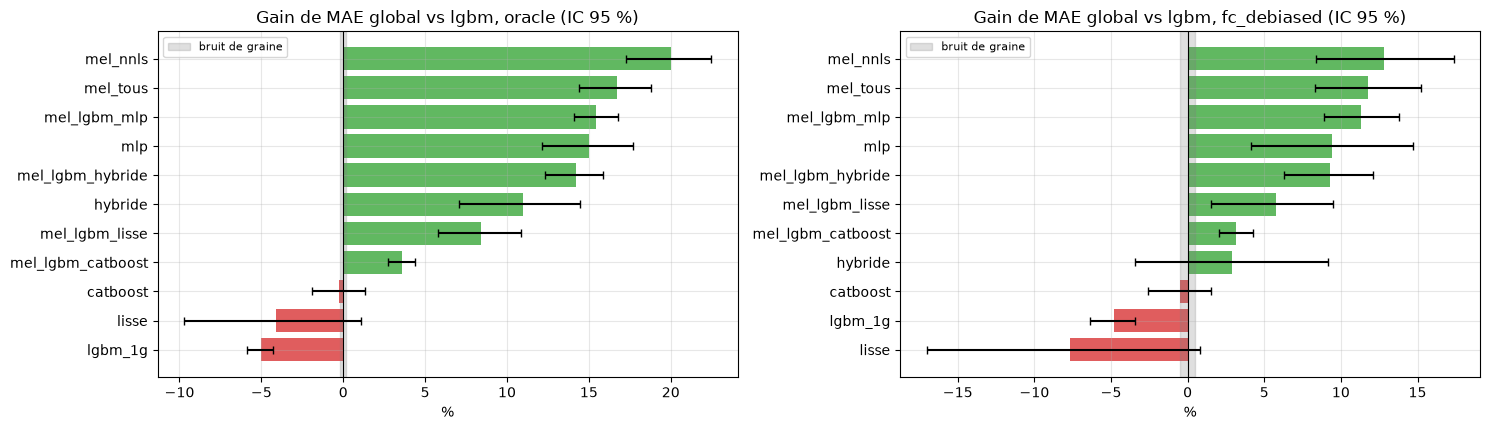

In [8]:
allnames = ["lgbm_1g", *SPECS, *names_b]
fig, axes = plt.subplots(1, len(MODES), figsize=(7.5 * len(MODES), 4.4), squeeze=False)
for ax, mode in zip(axes[0], MODES):
    t = pd.concat([SCREEN[mode], SCREEN_B[mode]]).loc[allnames].sort_values("gain_global")
    xerr = np.vstack([t["gain_global"] - t["lo_global"], t["hi_global"] - t["gain_global"]])
    ax.barh(t.index, t["gain_global"], xerr=xerr, color=np.where(t["gain_global"] >= 0, "tab:green", "tab:red"), alpha=0.75, capsize=3)
    ax.axvline(0, color="k", lw=0.8)
    nz = NOISE.get((mode, "global"), 0)
    ax.axvspan(-nz, nz, color="grey", alpha=0.25, label="bruit de graine")
    ax.set_title(f"Gain de MAE global vs lgbm, {mode} (IC 95 %)")
    ax.set_xlabel("%")
    ax.legend(fontsize=8)
plt.tight_layout()
save_fig("06_criblage_modeles")
plt.show()

## 7. Test d'extrapolation au froid

Même test que dans le notebook 05 : on retire de l'entraînement tous les jours dont la température moyenne est sous le 10ᵉ centile des jours de décembre à février, puis on évalue **uniquement** sur ces jours froids que le modèle n'a jamais vus (mode oracle). C'est là que l'on attend un avantage des modèles qui extrapolent (`lisse`, `hybride`, `mlp`).

In [9]:
win = T_DAY_OBS.loc[(T_DAY_OBS.index.month.isin([12, 1, 2])) & (T_DAY_OBS.index < HOLDOUT_START.tz_localize(None))]
THR = float(win.quantile(0.10))
cold_rows = T_DAY_OBS.reindex(LOCAL_DAY.to_numpy()).to_numpy() <= THR
SCOPE_MASK["extrap"] = T_DAY_OBS <= THR
print(f"Seuil : {THR:.1f} °C, {int(cold_rows.sum() / 48)} jours retirés de l'entraînement")

x_specs = {"lgbm": dict(kind="lgbm", seeds=SEEDS, rounds=ROUNDS), **SPECS}
for name, spec in x_specs.items():
    run_model(f"x_{name}", spec, exclude_train=cold_rows, modes=["oracle"])

rows = []
for name in x_specs:
    fr = eval_frame([name, f"x_{name}"], "oracle")
    froid = SCOPE_MASK["extrap"].reindex(LOCAL_DAY.reindex(fr.index).to_numpy()).fillna(False).to_numpy(dtype=bool)
    e_x, e_n = (fr[f"x_{name}"] - fr["y"]).abs()[froid].mean(), (fr[name] - fr["y"]).abs()[froid].mean()
    rows.append({"modèle": name, "MAE froid, extrapolation": e_x, "MAE froid, entraînement normal": e_n, "perte %": (e_x / e_n - 1) * 100})
EXTRAP = pd.DataFrame(rows).set_index("modèle")
tab = compare([f"x_{m}" for m in x_specs if m != "lgbm"], ref="x_lgbm", mode="oracle", scopes=("extrap",))
tab.index = [i.replace("x_", "") for i in tab.index]
EXTRAP_NUM = tab
display(EXTRAP.join(pretty(tab, scopes=("extrap",)).drop(columns="MAE")).round(1))
print("`gain` : par rapport à lgbm entraîné dans les mêmes conditions, sur les jours froids jamais vus. `perte` : dégradation due à l'extrapolation.")

Seuil : 1.7 °C, 127 jours retirés de l'entraînement
  x_lgbm                       7 entraînements,    586 s (83.7 s par entraînement)
  x_lisse                      7 entraînements,     24 s (3.4 s par entraînement)
  x_hybride                    7 entraînements,    424 s (60.5 s par entraînement)
  x_catboost                   7 entraînements,    511 s (73.0 s par entraînement)
  x_mlp                        7 entraînements,   9134 s (1304.9 s par entraînement)


,"MAE froid, extrapolation","MAE froid, entraînement normal",perte %,extrap (45 j)
modèle,,,,
lgbm,1692.9,1432.4,18.2,NaN
lisse,1201.3,960.7,25.0,+29.04 % [+4.64 ; +50.08] ✅
hybride,1251.0,912.9,37.0,+26.10 % [-0.21 ; +48.17] ⚪
catboost,1968.1,1467.0,34.2,-16.26 % [-24.98 ; -7.34] ❌
mlp,1065.9,1049.4,1.6,+37.04 % [+11.60 ; +55.24] ✅


`gain` : par rapport à lgbm entraîné dans les mêmes conditions, sur les jours froids jamais vus. `perte` : dégradation due à l'extrapolation.


## 8. Stabilité

Le gain est-il régulier dans le temps ? Décomposition par année, saison et tranche de température pour les meilleurs candidats (mode oracle et mode prévu).

In [10]:
def score(name):
    t = [pd.concat([SCREEN[m], SCREEN_B[m]]).loc[name] for m in MODES]
    ok = all(r["verdict_global"] != "❌" for r in t) and any(r["verdict_global"] in ("✅", "🟡") for r in t)
    return np.mean([r["gain_global"] for r in t]) if ok else -np.inf


ranking = pd.Series({n: score(n) for n in [*SPECS, *BLENDS] if n != "mel_nnls"}).sort_values(ascending=False)
CANDS = [n for n, s in ranking.items() if np.isfinite(s) and s > 0][:3]
print("Candidats (gain moyen positif, jamais ❌, au moins un ✅ ou 🟡) :", CANDS or "aucun")
for mode in MODES:
    for by in ("année", "saison", "tranche_T"):
        t = pd.DataFrame({n: slice_gain(n, "lgbm", mode, by) for n in CANDS}).T if CANDS else pd.DataFrame()
        if len(t):
            try:
                display(t.style.format("{:+.1f}").background_gradient(cmap="RdYlGn", axis=None, vmin=-8, vmax=8).set_caption(f"Gain de MAE (%) vs lgbm, {mode}, par {by}"))
            except Exception:
                display(t.round(1))

Candidats (gain moyen positif, jamais ❌, au moins un ✅ ou 🟡) : ['mel_tous', 'mel_lgbm_mlp', 'mlp']


date_heure,2018,2019,2020,2021,2022,2023,2024
mel_tous,+21.3,+19.0,+20.2,+15.1,+17.2,+10.1,+14.8
mel_lgbm_mlp,+18.2,+15.9,+14.0,+14.6,+17.5,+10.3,+15.2
mlp,+17.6,+17.8,+12.9,+13.5,+18.0,+5.7,+16.0


,hiver,mi-saison,été
mel_tous,+21.0,+20.8,-0.3
mel_lgbm_mlp,+16.8,+17.0,+9.6
mlp,+18.0,+17.3,+3.7


,<0,0-5,5-10,10-15,15-20,20-25,>25
mel_tous,+29.9,+22.4,+21.5,+19.3,+8.4,+0.0,+1.0
mel_lgbm_mlp,+23.1,+17.2,+16.8,+16.2,+12.1,+10.9,+10.4
mlp,+30.6,+21.0,+18.4,+14.8,+7.9,+5.3,+4.8


date_heure,2023,2024
mel_tous,+9.7,+13.9
mel_lgbm_mlp,+9.5,+13.1
mlp,+6.0,+12.9


,hiver,mi-saison,été
mel_tous,+15.7,+15.1,-3.0
mel_lgbm_mlp,+11.2,+15.3,+7.1
mlp,+9.7,+17.0,+0.2


,<0,0-5,5-10,10-15,15-20,20-25,>25
mel_tous,+26.6,+18.6,+14.3,+13.9,+5.4,-5.5,+0.4
mel_lgbm_mlp,+20.1,+14.5,+10.5,+11.2,+11.4,+6.3,+9.7
mlp,+35.9,+18.7,+7.5,+8.2,+6.5,+0.7,+4.2


## 9. Confirmation aveugle : 2025 et suivants

Ces données n'ont servi ni à choisir des modèles ni à régler quoi que ce soit (nombre d'époques compris). On refait la comparaison avec le rythme de réentraînement du profil (`confirm_retrain`) et le nombre d'arbres de production, pour les candidats de la section 8 et leurs composants, le tout comparé à `lgbm` réentraîné de la même façon. Les poids du mélange `mel_nnls` sont ceux appris sur la période de sélection, pas ceux de 2025.

In [11]:
CONF_ROUNDS = P["confirm_rounds"]


def conf_spec(m):
    s = dict(x_specs[m])
    for k in ("rounds", "iters"):
        if k in s:
            s[k] = CONF_ROUNDS
    return s


need = {"lgbm"}
for c in CANDS:
    need |= set(BLENDS[c]) if c in BLENDS else {c}
nnls_ok = W_NNLS is not None and CANDS and set(W_NNLS.index) <= need
print(f"Confirmation : {sorted(need)}, réentraînement tous les {P['confirm_retrain']} mois, {CONF_ROUNDS} arbres, {HOLDOUT_START.date()} à {TEST_END.date()}")
for m in sorted(need):
    run_model(f"conf_{m}", conf_spec(m), start=HOLDOUT_START, end=TEST_END, retrain=P["confirm_retrain"])

conf_names = []
for c in CANDS:
    if c in BLENDS:
        add_blend(f"conf_{c}", [f"conf_{p}" for p in BLENDS[c]])
    conf_names.append(f"conf_{c}")
if nnls_ok:
    add_blend("conf_mel_nnls", [f"conf_{p}" for p in W_NNLS.index], W_NNLS.to_numpy())
    conf_names.append("conf_mel_nnls")

CONF = {}
if conf_names:
    for m in MODES:
        mt = metrics_table(["conf_lgbm", *conf_names, *(["rte_j1"] if "rte_j1" in PRED else [])], m, HOLDOUT_START, TEST_END)
        cmp_ = compare(conf_names, ref="conf_lgbm", mode=m, start=HOLDOUT_START, end=TEST_END)
        CONF[m] = (mt, cmp_)
        print(f"\n=== Mode {m}, {int(mt['n'].iloc[0]):,} points communs ===")
        display(mt.round({"MAE": 0, "RMSE": 0, "biais": 0, "MAPE %": 2, "err_pointe": 0, "n": 0}))
        display(pretty(cmp_))
else:
    print("Aucun candidat : LightGBM reste le meilleur modèle du protocole.")

Confirmation : ['catboost', 'hybride', 'lgbm', 'lisse', 'mlp'], réentraînement tous les 3 mois, 1000 arbres, 2025-01-01 à 2026-07-01
  conf_catboost                6 entraînements,   4860 s (810.0 s par entraînement)
  conf_hybride                 6 entraînements,   2813 s (468.8 s par entraînement)
  conf_lgbm                    6 entraînements,   2354 s (392.3 s par entraînement)
  conf_lisse                   6 entraînements,     43 s (7.2 s par entraînement)
  conf_mlp                     6 entraînements,  10997 s (1832.9 s par entraînement)

=== Mode oracle, 26,204 points communs ===


,MAE,RMSE,biais,MAPE %,err_pointe,n
conf_lgbm,791.0,1089.0,-148.0,1.52,826.0,26204.0
conf_mel_tous,684.0,919.0,-152.0,1.33,757.0,26204.0
conf_mel_lgbm_mlp,697.0,951.0,-147.0,1.34,769.0,26204.0
conf_mlp,705.0,958.0,-146.0,1.36,784.0,26204.0
conf_mel_nnls,669.0,902.0,-152.0,1.29,749.0,26204.0
rte_j1,1379.0,1718.0,-1055.0,2.74,1418.0,26204.0


,MAE,global (546 j),froid (32 j),grand_froid (4 j)
variante,,,,
conf_mel_tous,684.0,+13.51 % [+10.32 ; +16.59] ✅,+15.36 % [+1.04 ; +26.73] 🟡,-5.04 % [+nan ; +nan] n/a
conf_mel_lgbm_mlp,697.0,+11.82 % [+9.58 ; +13.92] ✅,+10.70 % [-0.57 ; +19.44] ⚪,+0.39 % [+nan ; +nan] n/a
conf_mlp,705.0,+10.83 % [+5.97 ; +15.24] ✅,+10.04 % [-16.00 ; +30.73] ⚪,-5.84 % [+nan ; +nan] n/a
conf_mel_nnls,669.0,+15.36 % [+11.69 ; +18.90] ✅,+16.55 % [-2.34 ; +31.94] ⚪,-0.17 % [+nan ; +nan] n/a



=== Mode fc_debiased, 26,204 points communs ===


,MAE,RMSE,biais,MAPE %,err_pointe,n
conf_lgbm,803.0,1100.0,-147.0,1.55,861.0,26204.0
conf_mel_tous,699.0,940.0,-163.0,1.36,776.0,26204.0
conf_mel_lgbm_mlp,714.0,971.0,-159.0,1.37,792.0,26204.0
conf_mlp,727.0,984.0,-170.0,1.40,804.0,26204.0
conf_mel_nnls,685.0,925.0,-164.0,1.32,759.0,26204.0
rte_j1,1379.0,1718.0,-1055.0,2.74,1418.0,26204.0


,MAE,global (546 j),froid (32 j),grand_froid (4 j)
variante,,,,
conf_mel_tous,699.0,+13.00 % [+9.76 ; +16.08] ✅,+13.63 % [-0.42 ; +25.33] ⚪,-7.35 % [+nan ; +nan] n/a
conf_mel_lgbm_mlp,714.0,+11.14 % [+8.88 ; +13.25] ✅,+8.88 % [-2.02 ; +18.12] ⚪,-6.30 % [+nan ; +nan] n/a
conf_mlp,727.0,+9.47 % [+4.51 ; +13.75] ✅,+7.65 % [-17.11 ; +29.38] ⚪,-18.27 % [+nan ; +nan] n/a
conf_mel_nnls,685.0,+14.73 % [+11.03 ; +18.32] ✅,+15.00 % [-2.35 ; +30.85] ⚪,-3.84 % [+nan ; +nan] n/a


MAE (MW) par tranche de température nationale, mode fc_debiased, confirmation :


,conf_lgbm,conf_mel_tous,conf_mel_lgbm_mlp,conf_mlp,conf_mel_nnls,rte_j1,n demi-heures
temp_nat,,,,,,,
<0,1196.0,1116.0,1149.0,1209.0,1087.0,1505.0,381
0-5,1214.0,1007.0,1068.0,1058.0,977.0,1477.0,2600
5-10,924.0,750.0,812.0,821.0,751.0,1200.0,6332
10-15,760.0,650.0,668.0,679.0,641.0,1377.0,6837
15-20,594.0,566.0,536.0,569.0,548.0,1427.0,5188
20-25,604.0,552.0,550.0,584.0,546.0,1475.0,2930
>25,796.0,786.0,717.0,697.0,731.0,1535.0,1936


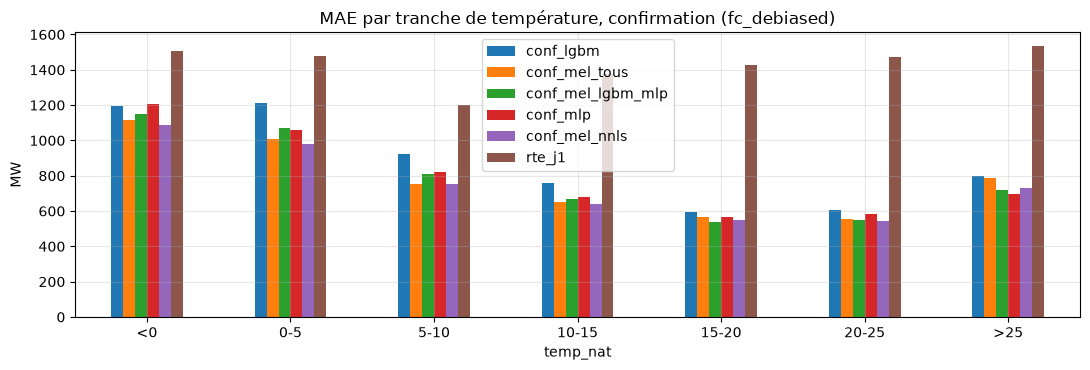

In [12]:
if conf_names:
    mode_c = MODES[-1]
    BINS, LABELS = [-np.inf, 0, 5, 10, 15, 20, 25, np.inf], ["<0", "0-5", "5-10", "10-15", "15-20", "20-25", ">25"]
    nm = ["conf_lgbm", *conf_names] + (["rte_j1"] if "rte_j1" in PRED else [])
    fr = eval_frame(nm, mode_c, HOLDOUT_START, TEST_END)
    band = pd.cut(df.loc[fr.index, "temp_nat"], BINS, labels=LABELS)
    tr_tab = pd.DataFrame({n: (fr[n] - fr["y"]).abs().groupby(band, observed=True).mean() for n in nm})
    tr_tab["n demi-heures"] = band.value_counts().reindex(tr_tab.index)
    print(f"MAE (MW) par tranche de température nationale, mode {mode_c}, confirmation :")
    display(tr_tab.round(0))
    tr_tab.drop(columns="n demi-heures").plot.bar(figsize=(11, 3.8), rot=0)
    plt.title(f"MAE par tranche de température, confirmation ({mode_c})")
    plt.ylabel("MW")
    plt.tight_layout()
    save_fig("06_confirmation_par_temperature")
    plt.show()

## 10. Coût et décision

Le coût compte : un modèle qui gagne 1 % de MAE mais coûte dix fois plus à entraîner et à maintenir n'est pas forcément un progrès. La règle de décision est écrite avant de regarder les résultats :

1. un modèle est **à envisager** si, sur la confirmation, son gain par rapport à `lgbm` est positif dans tous les modes, jamais ❌, ✅ ou 🟡 dans au moins un mode, et supérieur à 1 % ;
2. sinon, **LightGBM reste le choix de production**.

In [13]:
couts = pd.Series({m: FIT_SEC.get(m, np.nan) for m in ["lgbm", "lgbm_1g", "lisse", "hybride", "catboost", "mlp"] if m in FIT_SEC}, name="s par entraînement")
COUTS = pd.DataFrame({"s par entraînement": couts, "coût relatif à lgbm": couts / couts["lgbm"]})
print("Coût d'entraînement mesuré pendant le criblage (machine actuelle) :")
display(COUTS.round(2))

DECISION = pd.DataFrame()
if conf_names:
    rows = []
    for c in conf_names:
        r = {"modèle": c.replace("conf_", "")}
        for m in MODES:
            t = CONF[m][1].loc[c]
            r[f"gain {m} %"], r[f"verdict {m}"] = t["gain_global"], t["verdict_global"]
        gains = [r[f"gain {m} %"] for m in MODES]
        verdicts = [r[f"verdict {m}"] for m in MODES]
        r["à envisager"] = bool(all(g > 1.0 for g in gains) and "❌" not in verdicts and any(v in ("✅", "🟡") for v in verdicts))
        rows.append(r)
    DECISION = pd.DataFrame(rows).set_index("modèle")
    display(DECISION.round(2))
    print("À envisager :", list(DECISION.index[DECISION["à envisager"]]) or "aucun, LightGBM reste le choix de production")

OUT.mkdir(parents=True, exist_ok=True)
for m in MODES:
    pd.concat([SCREEN[m], SCREEN_B[m]]).to_csv(OUT / f"criblage_{m}.csv")
    if m in CONF:
        CONF[m][0].to_csv(OUT / f"confirmation_metriques_{m}.csv")
        CONF[m][1].to_csv(OUT / f"confirmation_gains_{m}.csv")
EXTRAP.join(EXTRAP_NUM[["gain_extrap", "lo_extrap", "hi_extrap", "verdict_extrap"]]).to_csv(OUT / "extrapolation.csv")
COUTS.to_csv(OUT / "couts.csv")
DECISION.to_csv(OUT / "decision.csv")
(OUT / "recommandation.json").write_text(json.dumps({
    "profil": PROFILE, "candidats": CANDS, "a_envisager": list(DECISION.index[DECISION["à envisager"]]) if len(DECISION) else [],
    "poids_mel_nnls": None if W_NNLS is None else W_NNLS.round(4).to_dict(), "epoques_mlp": EPOCHS,
}, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"\nRésultats écrits dans {OUT}")

Coût d'entraînement mesuré pendant le criblage (machine actuelle) :


,s par entraînement,coût relatif à lgbm
lgbm,80.91,1.00
lgbm_1g,17.69,0.22
lisse,3.14,0.04
hybride,79.42,0.98
catboost,91.19,1.13
mlp,889.48,10.99


,gain oracle %,verdict oracle,gain fc_debiased %,verdict fc_debiased,à envisager
modèle,,,,,
mel_tous,13.51,✅,13.00,✅,True
mel_lgbm_mlp,11.82,✅,11.14,✅,True
mlp,10.83,✅,9.47,✅,True
mel_nnls,15.36,✅,14.73,✅,True


À envisager : ['mel_tous', 'mel_lgbm_mlp', 'mlp', 'mel_nnls']

Résultats écrits dans c:\Users\<user>\Downloads\conso-rte\reports\model_experiments


## 11. Lecture et limites

- **Le bruit compte plus que la moyenne.** Les réseaux ont un bruit de graine plus élevé que LightGBM. Un écart de 1 à 2 % entre deux modèles reste dans l'incertitude, d'où le seuil de 1 % combiné à un IC dans la règle de décision.
- **Un seul jeu de données, peu d'événements froids.** Sous 0 °C, quelques vagues seulement. Le test d'extrapolation est le meilleur substitut, mais il mesure une capacité, pas un gain en exploitation.
- **La météo prévue est optimiste** (prévisions historiques, pas de vraies prévisions J-1 de 10 h). Les modèles très sensibles à la précision de la météo pourraient perdre plus en exploitation.
- **Rythme de réentraînement.** Le criblage réentraîne tous les 12 mois (profil `standard`), la confirmation tous les 3 mois : les niveaux de MAE sont légèrement plus élevés que la production mensuelle, mais toutes les comparaisons sont faites au même rythme.
- **Réglages peu explorés.** Profondeur de CatBoost, taille et régularisation du réseau, nombre de nœuds des splines : un réglage plus fin pourrait changer le classement, surtout pour les modèles les plus récents dans cette étude. Pour que cela reste équitable, il faudrait le faire sur la période de sélection uniquement.
- **Coût d'exploitation.** Chaque modèle ajouté est un artefact de plus à versionner, servir et surveiller. Le tableau de coût ne mesure que le temps d'entraînement.
- **Suite possible** si un mélange est retenu : l'intégrer dans `conso.model.Bundle` comme le `SeedEnsemble`, avec ses tests d'aller-retour de sauvegarde, puis rejouer le notebook 04.